<a href="https://colab.research.google.com/github/lilygracerobertson/Maths/blob/main/SCIE1500Materials/Week_9/LabFiles/Week09_Lab_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 9 Lab — Probability, Bayes' Theorem, and Medical Testing
**SCIE1500 — Analytical Methods for Scientists (UWA)**

**Lab format:** Work in your groups. Run all code cells in order, fill in the written prompts.

---
**This week:** We use probability and Bayes' theorem to evaluate the real-world performance of diagnostic tests — a critical skill in public health and clinical science.

---
## 📋 Scientific Scenario: A Positive Result Is Not a Diagnosis

![Diagnostic testing: population grid and PPV vs prevalence curve](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_9/images/W9_bayes_testing.svg?raw=1)

During a COVID-19 wave, health authorities use a rapid antigen test with the following properties:

- **Sensitivity** (true positive rate): 85% — if you have COVID, the test detects it 85% of the time.
- **Specificity** (true negative rate): 95% — if you do not have COVID, the test correctly gives a negative 95% of the time.
- **Community prevalence**: 2% of the population currently has COVID.

At first glance, 85% sensitivity and 95% specificity sound highly reliable. But a person who sees a positive result needs a different question answered: **given this result, how likely is it that I actually have COVID?** That probability depends not only on the test, but also on how common COVID is in the tested population.

**Decision question:** At 2% prevalence, should a positive rapid-test result trigger a major clinical or public-health decision on its own, or should it be confirmed? Build your answer from the expected counts, not just from the test's percentages.

---
## 🎯 Group Task & Learning Objectives

| Part | Topic | Time |
|------|-------|------|
| A | Bayes' theorem: algebra and intuition | ~25 min |
| B | Python calculation and verification | ~20 min |
| C | Sensitivity analysis: how prevalence changes everything | ~15 min |

By the end you should be able to apply Bayes' theorem to diagnostic testing, distinguish sensitivity and specificity from positive predictive value (PPV), interpret negative predictive value (NPV), and explain why prevalence changes what a positive result means.

**Lab focus:** Record one probability statement, one count from the 10,000-person table, and one implication for a testing decision. Together, they form a complete evidence-based explanation.

In [ ]:
# Run this cell first — loads libraries for today's lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Test parameters
sensitivity  = 0.85   # P(T+ | Disease)
specificity  = 0.95   # P(T- | No Disease)
prevalence   = 0.02   # P(Disease)

false_pos_rate = 1 - specificity   # P(T+ | No Disease)

print("Test characteristics:")
print(f"  Sensitivity:       {sensitivity:.0%}")
print(f"  Specificity:       {specificity:.0%}")
print(f"  False positive:    {false_pos_rate:.0%}")
print(f"  Prevalence:        {prevalence:.0%}")

Test characteristics:
  Sensitivity:       85%
  Specificity:       95%
  False positive:    5%
  Prevalence:        2%


---
## Part A: Bayes' Theorem (~25 min)

We want $P(D \mid T^+)$ — the probability of disease given a positive test (the **Positive Predictive Value**, PPV).

**Step 1** — Law of Total Probability for $P(T^+)$:
$$P(T^+) = P(T^+ \mid D) \cdot P(D) + P(T^+ \mid \bar{D}) \cdot P(\bar{D})$$
$$= 0.85 \times 0.02 + 0.05 \times 0.98 = 0.017 + 0.049 = 0.066$$

**Step 2** — Bayes' theorem:
$$P(D \mid T^+) = \frac{P(T^+ \mid D) \cdot P(D)}{P(T^+)} = \frac{0.017}{0.066} \approx 0.257$$

### A.1: Build the 10,000-person table by hand

**Do this calculation before running the Python cells below.** Convert each percentage into an expected number of people: first split 10,000 people into those with and without COVID, then use sensitivity and specificity to find the four outcomes. The later Python table will reproduce these same calculations so you can check, not replace, your work.

| Group | Count | Test result |
|-------|-------|-------------|
| Have COVID (2% of 10,000) | 200 | T+ : ?, T- : ? |
| No COVID (98% of 10,000) | 9,800 | T+ : ?, T- : ? |
| **Total T+** | ? | |

Use your completed table to calculate PPV as:
$$\mathrm{PPV} = \frac{\mathrm{true\ positives}}{\mathrm{all\ positive\ tests}}$$

```
ANSWERS:
Have Covid - T+ 200 x 0.85 = 170 (True Positives)
Have Covid - T- 200 x 0.05 = 30 (False Negative)

Have No Covid - T+ 9800 x 0.05 = 490 (Flase Positive)
Have No Covid - T- 9800 - 490 = 9310  (True Negatuve)

170 + 490 = 660 (all postive tests)

170/660 = 0.257 x 100

= 25.8 %

```

After you have completed the table, run the next cell to check the probability calculation, then run the Python confirmation table in A.2 to compare every count with your hand calculation.

In [ ]:
# A.1 — Verify Bayes' theorem
P_D    = prevalence
P_Dbar = 1 - P_D

# Joint probabilities
P_Tplus_and_D    = sensitivity * P_D
P_Tplus_and_Dbar = false_pos_rate * P_Dbar

P_Tplus = P_Tplus_and_D + P_Tplus_and_Dbar

PPV = P_Tplus_and_D / P_Tplus

print("Calculation:")
print(f"  P(T+ ∩ D)    = {sensitivity}×{P_D}   = {P_Tplus_and_D:.4f}")
print(f"  P(T+ ∩ D̄)   = {false_pos_rate}×{P_Dbar:.2f} = {P_Tplus_and_Dbar:.4f}")
print(f"  P(T+)        = {P_Tplus:.4f}")
print(f"  PPV = P(D|T+) = {PPV:.4f} ≈ {PPV:.1%}")
print(f"\n→ Only {PPV:.1%} of positive tests are truly positive!")

Calculation:
  P(T+ ∩ D)    = 0.85×0.02   = 0.0170
  P(T+ ∩ D̄)   = 0.050000000000000044×0.98 = 0.0490
  P(T+)        = 0.0660
  PPV = P(D|T+) = 0.2576 ≈ 25.8%

→ Only 25.8% of positive tests are truly positive!


## A.2: Confirm Your 10,000-Person Table with Python

You have already calculated these counts by hand. The next cell performs the **same calculation** in Python and prints the complete table, including false negatives and true negatives. Compare every output with your table; if a count differs, identify which percentage or denominator you used incorrectly.

**Before running:** predict which count will be larger at 2% prevalence: true positives or false positives. Then use the confirmed table to explain why a test can have high specificity and still produce many false alarms when the condition is uncommon.

**Interpretation prompt:** Use the checked counts in one sentence: “Out of every 10,000 people tested, ..., so a positive result means ...”.

In [ ]:
# A.2 — The 10,000 person table
N = 10000
n_D    = N * P_D
n_Dbar = N * P_Dbar

TP = sensitivity     * n_D       # true positives
FN = (1-sensitivity) * n_D       # false negatives
FP = false_pos_rate  * n_Dbar    # false positives
TN = specificity     * n_Dbar    # true negatives

print("Confusion matrix (10,000 people):")
print(f"{'':20s} {'T+':>8} {'T-':>8} {'Total':>8}")
print(f"{'Have COVID':20s} {TP:>8.0f} {FN:>8.0f} {n_D:>8.0f}")
print(f"{'No COVID':20s} {FP:>8.0f} {TN:>8.0f} {n_Dbar:>8.0f}")
print(f"{'Total':20s} {TP+FP:>8.0f} {FN+TN:>8.0f} {N:>8.0f}")
print(f"\nPPV = TP / (TP+FP) = {TP:.0f} / {TP+FP:.0f} = {TP/(TP+FP):.1%}")

Confusion matrix (10,000 people):
                           T+       T-    Total
Have COVID                170       30      200
No COVID                  490     9310     9800
Total                     660     9340    10000

PPV = TP / (TP+FP) = 170 / 660 = 25.8%


---
## Part B: A Negative Result Answers a Different Question (~20 min)

PPV asks whether a positive result is likely to be correct. **Negative Predictive Value (NPV)** asks the parallel question: given a negative result, what is the probability the person truly does not have COVID?

At low prevalence, most people are disease-free before they test, so negatives can be very trustworthy even while many positives are false alarms. This is not a contradiction; PPV and NPV condition on different groups of test results.

**Prompt before running:** Predict whether NPV will be higher or lower than PPV at 2% prevalence. After calculating it, explain what each value would mean for screening versus confirming an individual diagnosis.

In [ ]:
# B.1 — Negative Predictive Value (NPV): P(no disease | T-)
P_Tminus = 1 - P_Tplus
P_D_given_Tminus = ((1 - sensitivity) * P_D) / P_Tminus
NPV = 1 - P_D_given_Tminus

print(f"P(T-)   = {P_Tminus:.4f}")
print(f"P(D|T-) = {P_D_given_Tminus:.4f}  (prob. you have COVID despite negative test)")
print(f"NPV     = {NPV:.4f} = {NPV:.2%}  (prob. truly disease-free given negative test)")

P(T-)   = 0.9340
P(D|T-) = 0.0032  (prob. you have COVID despite negative test)
NPV     = 0.9968 = 99.68%  (prob. truly disease-free given negative test)


---
## Part C: Sensitivity Analysis — The Same Test, Different Meaning (~15 min)

The sensitivity and specificity remain fixed in the next plot. Only community prevalence changes. This lets us isolate a crucial idea: a test result does not have one universal meaning; its interpretation depends on the population being tested.

**Before plotting:** predict whether PPV rises or falls as prevalence increases. On the graph, identify the 2% point, then compare it with a higher-prevalence point. Explain which part of the Bayes denominator changes and why.

**Decision prompt:** A screening program may still be useful when PPV is low, but it needs a workflow for false positives. State what additional step would make a positive screening result safer to act on.

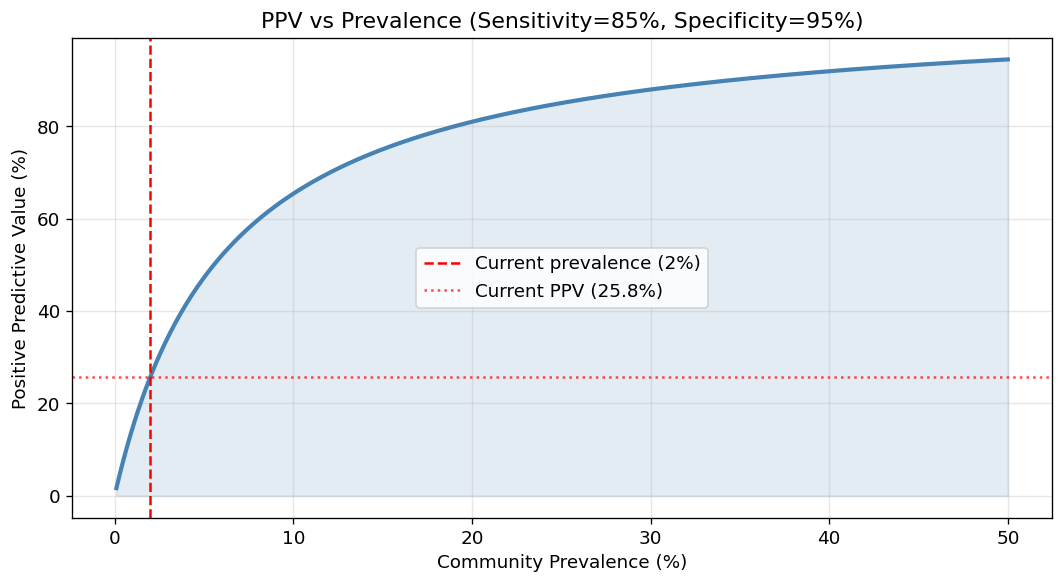

PPV at 2% prevalence:  25.8%
PPV at 10% prevalence: 65.4%
PPV at 30% prevalence: 87.9%


In [ ]:
# C.1 — PPV vs prevalence curve
prev_vals = np.linspace(0.001, 0.50, 500)

def bayes_PPV(prev, sens=sensitivity, spec=specificity):
    'Positive Predictive Value for given prevalence.'
    fpr = 1 - spec
    P_pos = sens * prev + fpr * (1 - prev)
    return sens * prev / P_pos

ppv_vals = bayes_PPV(prev_vals)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(prev_vals * 100, ppv_vals * 100, "steelblue", lw=2.5)
ax.axvline(prevalence * 100, color="red", ls="--", label=f"Current prevalence ({prevalence:.0%})")
ax.axhline(PPV * 100, color="red", ls=":", alpha=0.7, label=f"Current PPV ({PPV:.1%})")
ax.fill_between(prev_vals * 100, ppv_vals * 100, alpha=0.15, color="steelblue")
ax.set_xlabel("Community Prevalence (%)")
ax.set_ylabel("Positive Predictive Value (%)")
ax.set_title(f"PPV vs Prevalence (Sensitivity={sensitivity:.0%}, Specificity={specificity:.0%})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PPV at 2% prevalence:  {bayes_PPV(0.02):.1%}")
print(f"PPV at 10% prevalence: {bayes_PPV(0.10):.1%}")
print(f"PPV at 30% prevalence: {bayes_PPV(0.30):.1%}")

✏️ **Group Discussion:**

1. Why is the PPV only ~26% even though the test is 85% sensitive? Where do the false positives come from?
2. At what prevalence does the PPV reach 50%? Use your plot to estimate, then verify with Python.
3. Should health authorities use this test for population screening at 2% prevalence? What are the consequences of a false positive for the patient?

```
DISCUSSION:
sensetivty - how likley the test is to pick up the disease
specificty - how accurate the test is at idetifying the disease

Becuase the community prevelence is low, not many people actually will get a true postive, therefore, the rate of flase positives is higher. This is misrepresentative of the overall number of true positives in the community.

Esitmate that when revelence = 50%, PPV = 5%


prevelence x sensetivity/ (prevelence x sensetivity) +(1 - prevelence) x (1 - specificty)

0.85P/0.85P + (1-0.95) x (1-P) = 50% or 0.5
0.85P/0.85P + 0.05 x (1-P)   *0.05 is expanded/applied to the other parts of th denomonator
0.5 x 0.85P
0.85P = 0.425P + 0.025 - 0.025P
0.85P = 0.4P + 0.025
0.45P = 0.025
P = 0.025/0.45
P = 0.0556
P = 5.56%

No health authorities shouldn't use this test at 2% prevelence. Flase postives would result in isolation, medication and medical treatment for people who don't need it, actally risking their health. Impacts their jobs, personal lives ect, thus impacting wider community and economy. This is misleading and negatively impacts the community.
```


---
## ✅ Submission Exercise — Batch 3 (due Tuesday 29 September, 11:59 pm)

**Submit via LMS. Covers Weeks 7–9 (definite integrals, ODEs, probability).**

Work individually. Show all working. Write Python code where indicated.
Upload your **completed notebook (.ipynb)** to the LMS — do not submit screenshots.
        

In [ ]:

# Fill in your details before submitting
student_name   = "Lily Robertson"
student_number = "25286485"
print(f"Submission by: {student_name}  |  Student #{student_number}")


Submission by: Lily Robertson  |  Student #25286485



---
### Q1 — Consumer and Producer Surplus (Week 7)

A freshwater prawn market in the Ord River region has:
- Demand: $Q_d = 400 - 2P$ (kg/week)
- Supply: $Q_s = -60 + 3P$ (kg/week)

**(a)** Find the equilibrium price $P^*$ and quantity $Q^*$ algebraically.
        


**Answer (a):**

....

        


**(b)** Derive the inverse demand and inverse supply functions.
        


**Answer (b):**

...write your working here...
        


**(c)** Calculate CS and PS using the triangle formulas. Show all working.
        


**Answer (c):**

...write your working here...
        


**(d)** Verify CS and PS using numerical integration (`numpy.trapz`).
        

In [ ]:

# Q1d — verify with integration
import numpy as np

def demand_P(Q):
    # inverse demand: P as a function of Q — your code here
    pass

def supply_P(Q):
    # inverse supply: P as a function of Q — your code here
    pass

# Your integration code here




---
### Q2 — Predator-Prey Dynamics (Week 8)

A quoll-rat system in the Pilbara:

$$\frac{dR}{dt} = 0.6R - 0.003RQ, \qquad \frac{dQ}{dt} = -0.2Q + 0.001RQ$$

where $R$ = rat population, $Q$ = quoll population.

**(a)** Find the coexistence equilibrium $(R^*, Q^*)$. Show your algebra.
        


**Answer (a):**

coesistence equilibrium is when both populations are greater than 0 and their populations are stable (rate of change is 0)

dR/dt = 0

0.6 - 0.003RQ = 0

R(0.6 - 0.003Q) = 0

solve for Q

0.6 - 0.003Q = 0

0.003Q = 0.6

Q* = 0.6/0.003 = 200

dQ/dt = 0

-0.2Q + 0.001RQ = 0

Q(-0.2 + 0.001R) = 0

solve for R

-0.2 + 0.001R = 0
0.001R = 0.2
R = 0.2/0.001 = 200

Coexistance Equilibrium (R*, Q*) = (200,200)



**(b)** Identify the rat nullcline and quoll nullcline. What does each represent biologically?
        


**Answer (b):**

Rat Nullacline (where the rate of change is 0 for the population)

dR/dt = 0

R = 0, Q = 200

R = 0 represents where rat population is 0, meaning no new rats can be born.

Q = 200 represents the critical predator threshold, where the quoll population is exactly 200, the predation rate prefectly blalances the natural growth of the rats, keeping their population constant.

Quoll Nullacline (where the rate of hange is 0 for the population)

dQ/dt = 0

Q = 0, R = 200

Q = 0 represenst where the quoll population is 0, meanning no new quolls can be born

R = 200 represets the cirtical prey threshold, where the rat population is exactly 200, the available food supply provides just enought energy to perfectly balance the natural death rate of the quolls


**(c)** Simulate the system for 30 years starting from $R_0 = 500$, $Q_0 = 80$ using Euler's method (dt = 0.01). Plot both populations over time.
        

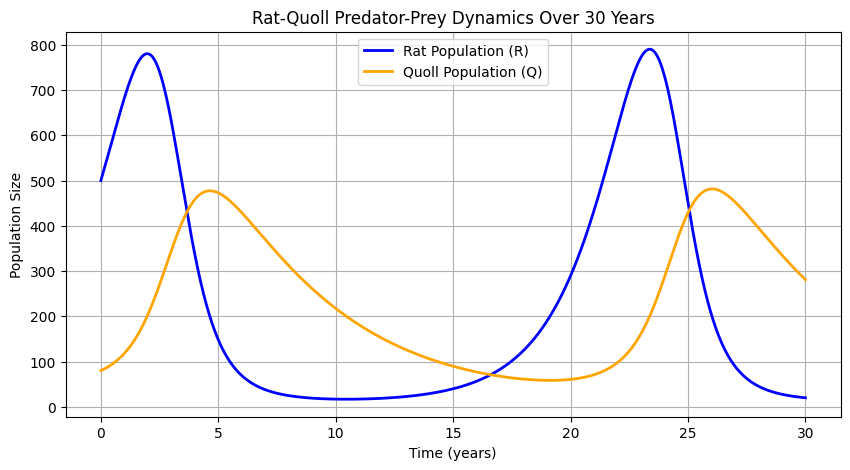

In [2]:

# Your code # q2c - Euler method simulation
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Parameters
r_R = 0.6; a = 0.003; d_Q = 0.2; b = 0.001

# Simulation time constraints
t_max = 30 # Maximum time in years
dt = 0.01 # Time step
num_steps = int(t_max / dt)

# Initialize arrays to hold values
t = np.linspace(0, t_max, num_steps + 1)
R = np.zeros(num_steps + 1)
Q = np.zeros(num_steps + 1)

# Set initial conditions
R[0] = 500
Q[0] = 80

# Euler's method loop
for i in range(num_steps):
    dR = (r_R * R[i] - a * R[i] * Q[i]) * dt
    dQ = (-d_Q * Q[i] + b * R[i] * Q[i]) * dt
    R[i+1] = R[i] + dR
    Q[i+1] = Q[i] + dQ

# Plotting both populations over time
plt.figure(figsize=(10, 5))
plt.plot(t, R, label='Rat Population (R)', color='blue', linewidth=2)
plt.plot(t, Q, label='Quoll Population (Q)', color='orange', linewidth=2)
plt.xlabel('Time (years)')
plt.ylabel('Population Size')
plt.title('Rat-Quoll Predator-Prey Dynamics Over 30 Years')
plt.legend()
plt.grid(True)
plt.show()


**(d)** Do the populations oscillate or converge? Is the equilibrium reached?
        


**Answer (d):**

the populations oscillate, the populations create a self-sustaining cycle over time

the equilibrium is not reached (200,200) where the populations balance each other perfectly. Instead they continiously oscillate in a cycle, fluctuating rather than stabilising.


---
### Q3 — Bayes' Theorem (Week 9)

A breast cancer screening test has sensitivity 90% and specificity 92%. Background prevalence in the 50–60 age group is 1.5%.

**(a)** Calculate $P(T^+)$ — the probability a randomly selected person tests positive.
        


**Answer (a):**

sensetivity = 90% = 0.9

specificity = 92% = 0.92

Prevelence = 1.5% = 0.0015

False negative = 1 - 0.9 = 0.1 = 10%

False positive = 1 = 0.92 = 0.08 = 8%

Healthy population = 1 - 0.015 = 0.985 = 98.5%

P(T^+) = (0.9 x 0.015) + (0.08 x 0.095)

P(T+) = 0.0135 + 0.0788

P(T^+) = 0.0923 = 9.23% chance of a postive test



**(b)** Calculate the PPV using Bayes' theorem. Show each step.
        


**Answer (b):**

Bayes' Theorum: P(D^+ | T^+) = P(T^+ | D^+) x P(D^+) / P(T^+)

P(D^+ | T^+) = 0.0135/0.0923

= 0.14626

PPV = 14.63%

        


**(c)** Plot PPV vs prevalence for prevalence ranging from 0.1% to 20%. Annotate the 1.5% prevalence point.
        

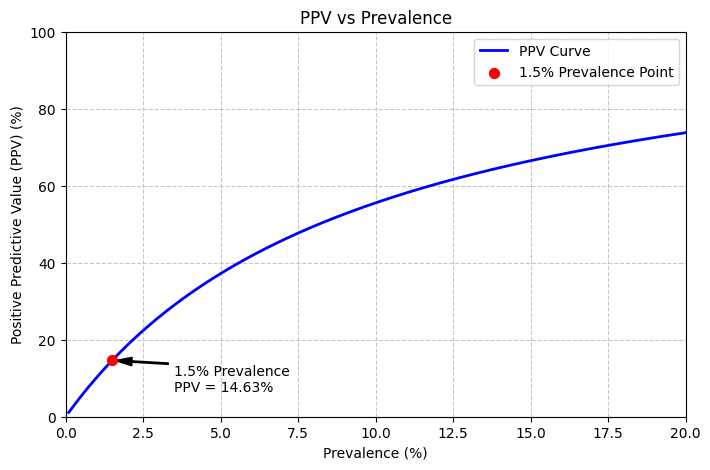

In [3]:

# Q3c — PPV vs prevalence
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sensitivity = 0.90
specificity = 0.92

# Your code here

import matplotlib.pyplot as plt
import numpy as np

# 1. Define given test characteristics
sensitivity = 0.90
specificity = 0.92
false_positive_rate = 1 - specificity # 0.08

# 2. Create an array of prevalence values from 0.1% to 20%
# We divide by 100 to convert percentages to probabilities
prevalence_range = np.linspace(0.1 / 100, 20.0 / 100, 500)

# 3. Calculate PPV for each prevalence value using Bayes' Theorem formula
numerator = sensitivity * prevalence_range
denominator = (sensitivity * prevalence_range) + (
    false_positive_rate * (1 - prevalence_range)
)
ppv_range = numerator / denominator

# 4. Calculate the specific values for the 1.5% target point
target_prevalence = 1.5 / 100
target_ppv = (sensitivity * target_prevalence) / (
    (sensitivity * target_prevalence)
    + (false_positive_rate * (1 - target_prevalence))
)

# 5. Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(
    prevalence_range * 100,
    ppv_range * 100,
    label="PPV Curve",
    color="blue",
    linewidth=2,
)

# 6. Annotate the 1.5% prevalence point
plt.scatter(
    target_prevalence * 100,
    target_ppv * 100,
    color="red",
    s=50,
    zorder=5,
    label="1.5% Prevalence Point",
)
plt.annotate(
    f"1.5% Prevalence\nPPV = {target_ppv*100:.2f}%",
    xy=(target_prevalence * 100, target_ppv * 100),
    xytext=(target_prevalence * 100 + 2, target_ppv * 100 - 8),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
)

# 7. Chart formatting
plt.title("PPV vs Prevalence")
plt.xlabel("Prevalence (%)")
plt.ylabel("Positive Predictive Value (PPV) (%)")
plt.xlim(0, 20)
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()


**(d)** At what prevalence would PPV reach 50%? Solve algebraically or numerically.
        


**Answer (d):**

PPV = sensetivity x P / (sensetivity x P) + (FPR x (1-P))

0.5 = 0.9P / 0.9P + 0.08(1-P)

90P = 0.08(1-P)

0.9P = 0.08 - 0.08P

0.9P + 0.08P = 0.08

0.98P = 0.08

P = 0.08/0.98 = 4/49

P = 0.08163

PPV = 8.16%